# Bayesian Inference Basics

Topic 13 of the Statistical Inference & Hypothesis Testing repo. Every topic so far worked within the **frequentist** framework: parameters are fixed unknowns, and probability describes long-run frequency across repeated sampling (Topic 03's confidence interval coverage simulation was the clearest example). This notebook introduces the **Bayesian** alternative: parameters themselves have probability distributions representing belief, updated by data via Bayes' theorem. It builds the Beta-Binomial and Normal-Normal conjugate models from scratch, directly contrasts a credible interval's interpretation against Topic 03's confidence interval, and closes with a practical Bayesian A/B test revisiting Topic 10.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Setup complete.")

Setup complete.


## 1. Bayes' Theorem and the Beta-Binomial Conjugate Model

$$P(\theta \mid \text{data}) = \frac{P(\text{data} \mid \theta) \, P(\theta)}{P(\text{data})}$$

For a Binomial likelihood (e.g. conversions out of trials) with a Beta prior, the posterior is *also* Beta — a conjugate pair, meaning no numerical integration is ever needed, just simple parameter updates:

$$\theta \sim \text{Beta}(\alpha, \beta) \ \Rightarrow \ \theta \mid \text{data} \sim \text{Beta}(\alpha + x, \ \beta + n - x)$$

In [2]:
def beta_binomial_update(prior_alpha, prior_beta, successes, trials):
    posterior_alpha = prior_alpha + successes
    posterior_beta = prior_beta + (trials - successes)
    return posterior_alpha, posterior_beta

print("Beta-Binomial conjugate update function defined.")

Beta-Binomial conjugate update function defined.


In [3]:
# A weakly informative prior (Beta(1,1) = uniform over [0,1], expressing no strong belief)
prior_alpha, prior_beta = 1, 1
observed_successes, observed_trials = 7, 20
print(f"Prior: Beta({prior_alpha}, {prior_beta})  |  Data: {observed_successes}/{observed_trials}")

Prior: Beta(1, 1)  |  Data: 7/20


In [4]:
post_alpha, post_beta = beta_binomial_update(prior_alpha, prior_beta, observed_successes, observed_trials)
posterior_mean = post_alpha / (post_alpha + post_beta)
mle_estimate = observed_successes / observed_trials

print(f"Prior: Beta({prior_alpha}, {prior_beta})  (uniform, weakly informative)")
print(f"Data: {observed_successes} successes out of {observed_trials} trials")
print(f"Posterior: Beta({post_alpha}, {post_beta})")
print(f"Posterior mean: {posterior_mean:.4f}")
print(f"Frequentist MLE (successes/trials): {mle_estimate:.4f}")
print(f"Difference: {abs(posterior_mean - mle_estimate):.4f} -- with a uniform prior, the two nearly coincide.")

Prior: Beta(1, 1)  (uniform, weakly informative)
Data: 7 successes out of 20 trials
Posterior: Beta(8, 14)
Posterior mean: 0.3636
Frequentist MLE (successes/trials): 0.3500
Difference: 0.0136 -- with a uniform prior, the two nearly coincide.


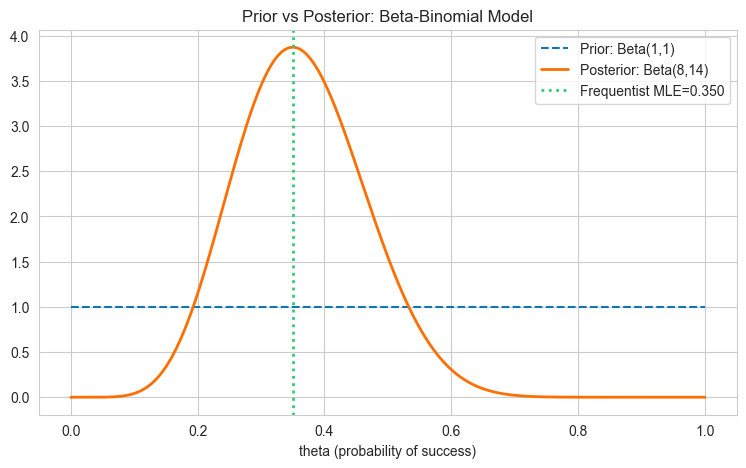

In [5]:
fig, ax = plt.subplots()
theta_grid = np.linspace(0, 1, 500)
ax.plot(theta_grid, stats.beta.pdf(theta_grid, prior_alpha, prior_beta), color="#0e75b6", linestyle="--", label=f"Prior: Beta({prior_alpha},{prior_beta})")
ax.plot(theta_grid, stats.beta.pdf(theta_grid, post_alpha, post_beta), color="#FF6F00", linewidth=2, label=f"Posterior: Beta({post_alpha},{post_beta})")
ax.axvline(mle_estimate, color="#2ecc71", linestyle=":", linewidth=2, label=f"Frequentist MLE={mle_estimate:.3f}")
ax.set_xlabel("theta (probability of success)")
ax.set_title("Prior vs Posterior: Beta-Binomial Model")
ax.legend()
plt.show()

## 2. The Effect of Prior Strength: Weak vs Strong Priors

A Beta prior's "strength" is controlled by $\alpha+\beta$ (its effective sample size). This section applies the *same* observed data to a weak prior and a strong (confidently wrong) prior, showing how much each pulls the posterior away from the data alone.

In [6]:
weak_prior = (1, 1)       # Beta(1,1): uniform, effectively 2 'prior observations'
strong_prior = (40, 10)   # Beta(40,10): confidently believes theta is near 0.8, effectively 50 'prior observations'
print(f"Weak prior: Beta{weak_prior}  |  Strong prior: Beta{strong_prior}")

Weak prior: Beta(1, 1)  |  Strong prior: Beta(40, 10)


In [7]:
post_weak = beta_binomial_update(*weak_prior, observed_successes, observed_trials)
post_strong = beta_binomial_update(*strong_prior, observed_successes, observed_trials)

mean_weak = post_weak[0] / sum(post_weak)
mean_strong = post_strong[0] / sum(post_strong)

print(f"Same data: {observed_successes}/{observed_trials} = {mle_estimate:.4f} observed rate")
print(f"Weak prior Beta{weak_prior}   -> posterior mean {mean_weak:.4f} (close to the data)")
print(f"Strong prior Beta{strong_prior} -> posterior mean {mean_strong:.4f} (pulled toward the prior's belief of ~0.8)")
print(f"\nThe strong prior resists the data much more -- exactly the expected behavior: "
      f"a confident prior needs more evidence to be overturned.")

Same data: 7/20 = 0.3500 observed rate
Weak prior Beta(1, 1)   -> posterior mean 0.3636 (close to the data)
Strong prior Beta(40, 10) -> posterior mean 0.6714 (pulled toward the prior's belief of ~0.8)

The strong prior resists the data much more -- exactly the expected behavior: a confident prior needs more evidence to be overturned.


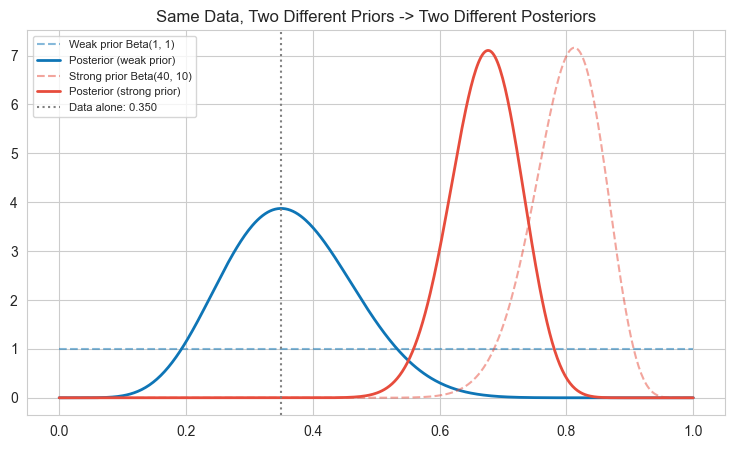

In [8]:
fig, ax = plt.subplots()
ax.plot(theta_grid, stats.beta.pdf(theta_grid, *weak_prior), color="#0e75b6", linestyle="--", alpha=0.5, label=f"Weak prior Beta{weak_prior}")
ax.plot(theta_grid, stats.beta.pdf(theta_grid, *post_weak), color="#0e75b6", linewidth=2, label=f"Posterior (weak prior)")
ax.plot(theta_grid, stats.beta.pdf(theta_grid, *strong_prior), color="#e74c3c", linestyle="--", alpha=0.5, label=f"Strong prior Beta{strong_prior}")
ax.plot(theta_grid, stats.beta.pdf(theta_grid, *post_strong), color="#e74c3c", linewidth=2, label=f"Posterior (strong prior)")
ax.axvline(mle_estimate, color="gray", linestyle=":", label=f"Data alone: {mle_estimate:.3f}")
ax.set_title("Same Data, Two Different Priors -> Two Different Posteriors")
ax.legend(fontsize=8)
plt.show()

In [9]:
# Show the strong prior's influence shrinking as MORE data accumulates
large_trials, large_successes = 500, 175  # same underlying rate (0.35), much more data
post_weak_large = beta_binomial_update(*weak_prior, large_successes, large_trials)
post_strong_large = beta_binomial_update(*strong_prior, large_successes, large_trials)
mean_weak_large = post_weak_large[0] / sum(post_weak_large)
mean_strong_large = post_strong_large[0] / sum(post_strong_large)

print(f"With MORE data ({large_successes}/{large_trials} = {large_successes/large_trials:.4f}):")
print(f"Weak prior posterior mean:   {mean_weak_large:.4f}")
print(f"Strong prior posterior mean: {mean_strong_large:.4f}")
print(f"Gap between the two posteriors: {abs(mean_weak_large - mean_strong_large):.4f} "
      f"(vs {abs(mean_weak - mean_strong):.4f} with the smaller dataset) -- "
      f"the prior's influence shrinks as data accumulates, regardless of how strong it was.")

With MORE data (175/500 = 0.3500):
Weak prior posterior mean:   0.3506
Strong prior posterior mean: 0.3909
Gap between the two posteriors: 0.0403 (vs 0.3078 with the smaller dataset) -- the prior's influence shrinks as data accumulates, regardless of how strong it was.


## 3. Sequential Updating: the Posterior Doesn't Care About Data Order

A core Bayesian property: updating on data incrementally (batch by batch) produces the *exact same* final posterior as updating on all the data at once — the order and grouping of updates is irrelevant.

In [10]:
batches = [(3, 8), (2, 6), (2, 6)]  # (successes, trials) in three separate batches, same totals as before

running_alpha, running_beta = weak_prior
for successes_i, trials_i in batches:
    running_alpha, running_beta = beta_binomial_update(running_alpha, running_beta, successes_i, trials_i)
print(f"Sequential posterior after {len(batches)} batches: Beta({running_alpha}, {running_beta})")

Sequential posterior after 3 batches: Beta(8, 14)


In [11]:
total_successes = sum(s for s, t in batches)
total_trials = sum(t for s, t in batches)
one_shot_alpha, one_shot_beta = beta_binomial_update(*weak_prior, total_successes, total_trials)

print(f"Sequential updating across {len(batches)} batches: final posterior Beta({running_alpha}, {running_beta})")
print(f"One-shot update on all {total_trials} trials at once:  posterior Beta({one_shot_alpha}, {one_shot_beta})")
assert (running_alpha, running_beta) == (one_shot_alpha, one_shot_beta)
print("Confirmed: identical posteriors, regardless of whether data arrived in batches or all at once.")

Sequential updating across 3 batches: final posterior Beta(8, 14)
One-shot update on all 20 trials at once:  posterior Beta(8, 14)
Confirmed: identical posteriors, regardless of whether data arrived in batches or all at once.


## 4. Credible Interval vs. Confidence Interval: the Real Interpretive Difference

Topic 03 built a 95% confidence interval and showed the correct frequentist interpretation requires talking about the *procedure* across repeated sampling, never a single realized interval. A Bayesian **credible interval** makes the more intuitive-sounding statement legitimate — but only because it's answering a genuinely different question.

In [12]:
credible_lo, credible_hi = stats.beta.ppf([0.025, 0.975], post_alpha, post_beta)
print(f"95% credible interval for theta: [{credible_lo:.4f}, {credible_hi:.4f}]")
print(f"\nCORRECT Bayesian statement: 'Given this prior and this data, there is a 95% probability "
      f"that theta lies in [{credible_lo:.4f}, {credible_hi:.4f}].' This IS a valid probability statement "
      f"about theta itself, because in the Bayesian framework theta is treated as a random variable with "
      f"a genuine posterior distribution -- unlike Topic 03's frequentist confidence interval, where theta "
      f"is a fixed unknown and only the INTERVAL varies across hypothetical repeated samples.")

95% credible interval for theta: [0.1811, 0.5697]

CORRECT Bayesian statement: 'Given this prior and this data, there is a 95% probability that theta lies in [0.1811, 0.5697].' This IS a valid probability statement about theta itself, because in the Bayesian framework theta is treated as a random variable with a genuine posterior distribution -- unlike Topic 03's frequentist confidence interval, where theta is a fixed unknown and only the INTERVAL varies across hypothetical repeated samples.


In [13]:
# Verify the credible interval's OWN frequentist coverage under the SAME prior used to build it -- a
# cross-framework check: does a Bayesian interval, evaluated under repeated sampling, also behave sensibly?
rng_coverage = np.random.default_rng(20)
true_theta_check = 0.35
n_repeats_bayes_coverage = 5000
n_trials_check = 20
contains_true_theta = 0
for _ in range(n_repeats_bayes_coverage):
    sim_successes = rng_coverage.binomial(n_trials_check, true_theta_check)
    sim_post_a, sim_post_b = beta_binomial_update(*weak_prior, sim_successes, n_trials_check)
    lo, hi = stats.beta.ppf([0.025, 0.975], sim_post_a, sim_post_b)
    if lo <= true_theta_check <= hi:
        contains_true_theta += 1

empirical_coverage = contains_true_theta / n_repeats_bayes_coverage
print(f"Under a WEAK (near-uniform) prior, repeated-sampling coverage of the 95% credible interval: {empirical_coverage:.4f}")
print(f"\nWith an uninformative prior, the credible interval's coverage under repeated sampling is "
      f"{'close to the nominal 95%' if abs(empirical_coverage - 0.95) < 0.03 else 'somewhat off from the nominal 95%'} -- "
      f"a nice cross-framework sanity check, though matching frequentist coverage is a BONUS property here, "
      f"not the credible interval's actual defining guarantee (which is the Bayesian probability statement above).")

Under a WEAK (near-uniform) prior, repeated-sampling coverage of the 95% credible interval: 0.9692

With an uninformative prior, the credible interval's coverage under repeated sampling is close to the nominal 95% -- a nice cross-framework sanity check, though matching frequentist coverage is a BONUS property here, not the credible interval's actual defining guarantee (which is the Bayesian probability statement above).


In [14]:
# Direct numeric comparison: Wilson CI (Topic 03) vs this Bayesian credible interval, same data
def wilson_ci(successes, n, confidence_level=0.95):
    p_hat = successes / n
    z = stats.norm.ppf(1 - (1 - confidence_level) / 2)
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denom
    margin = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
    return center - margin, center + margin

print("Wilson CI function (from Topic 03) redefined for comparison.")

Wilson CI function (from Topic 03) redefined for comparison.


In [15]:
wilson_lo, wilson_hi = wilson_ci(observed_successes, observed_trials)
print(f"Wilson 95% confidence interval (Topic 03, frequentist): [{wilson_lo:.4f}, {wilson_hi:.4f}]")
print(f"95% credible interval (Bayesian, uniform prior):         [{credible_lo:.4f}, {credible_hi:.4f}]")
print(f"\nWith a UNIFORM (uninformative) prior, the two intervals are numerically "
      f"{'very close' if abs(wilson_lo-credible_lo)+abs(wilson_hi-credible_hi) < 0.05 else 'somewhat different'} -- "
      f"a well-known result: an uninformative-prior Bayesian credible interval and a well-constructed "
      f"frequentist CI often nearly coincide numerically, even though their INTERPRETATIONS remain fundamentally different.")

Wilson 95% confidence interval (Topic 03, frequentist): [0.1812, 0.5671]
95% credible interval (Bayesian, uniform prior):         [0.1811, 0.5697]

With a UNIFORM (uninformative) prior, the two intervals are numerically very close -- a well-known result: an uninformative-prior Bayesian credible interval and a well-constructed frequentist CI often nearly coincide numerically, even though their INTERPRETATIONS remain fundamentally different.


## 5. The Normal-Normal Conjugate Model

For a Normal likelihood with known variance $\sigma^2$ and a Normal prior on the mean, the posterior is also Normal, with the posterior mean a **precision-weighted average** of the prior mean and the sample mean:

$$\mu_{\text{post}} = \frac{\frac{\mu_0}{\sigma_0^2} + \frac{n\bar{x}}{\sigma^2}}{\frac{1}{\sigma_0^2} + \frac{n}{\sigma^2}}, \qquad \sigma_{\text{post}}^2 = \left(\frac{1}{\sigma_0^2} + \frac{n}{\sigma^2}\right)^{-1}$$

In [16]:
def normal_normal_update(prior_mean, prior_var, data, known_sigma):
    n = len(data)
    sample_mean = data.mean()
    prior_precision = 1 / prior_var
    data_precision = n / known_sigma ** 2
    posterior_var = 1 / (prior_precision + data_precision)
    posterior_mean = posterior_var * (prior_mean * prior_precision + sample_mean * data_precision)
    return posterior_mean, posterior_var

print("Normal-Normal conjugate update function defined.")

Normal-Normal conjugate update function defined.


In [17]:
prior_mean_nn, prior_var_nn = 100, 25   # a moderately confident prior belief: mu around 100, std=5
known_sigma_nn = 15                      # known population std of the data-generating process
true_mu_nn = 108
data_nn = np.random.normal(true_mu_nn, known_sigma_nn, size=10)
print(f"Prior: N({prior_mean_nn},{prior_var_nn})  |  Data (n=10): sample mean={data_nn.mean():.4f}")

Prior: N(100,25)  |  Data (n=10): sample mean=114.7209


In [18]:
post_mean_nn, post_var_nn = normal_normal_update(prior_mean_nn, prior_var_nn, data_nn, known_sigma_nn)
print(f"Prior: N({prior_mean_nn}, {prior_var_nn})")
print(f"Data (n={len(data_nn)}): sample mean = {data_nn.mean():.4f}")
print(f"Posterior: N({post_mean_nn:.4f}, {post_var_nn:.4f})")
print(f"\nThe posterior mean ({post_mean_nn:.4f}) sits BETWEEN the prior mean ({prior_mean_nn}) "
      f"and the sample mean ({data_nn.mean():.4f}) -- a precision-weighted compromise, "
      f"pulled toward whichever source (prior or data) carries more precision (less variance).")

Prior: N(100, 25)
Data (n=10): sample mean = 114.7209
Posterior: N(107.7479, 11.8421)

The posterior mean (107.7479) sits BETWEEN the prior mean (100) and the sample mean (114.7209) -- a precision-weighted compromise, pulled toward whichever source (prior or data) carries more precision (less variance).


## 6. Bayesian and Frequentist Estimates Converge as Data Accumulates

Regardless of the prior, as $n \to \infty$ the data's precision dominates and the posterior mean converges to the frequentist MLE. This section demonstrates that convergence directly, even starting from a deliberately biased prior.

In [19]:
sample_sizes_converge = [5, 20, 100, 1000]
rng_converge = np.random.default_rng(1)
convergence_rows = []
for n_test in sample_sizes_converge:
    data_n = rng_converge.normal(true_mu_nn, known_sigma_nn, size=n_test)
    post_mean_n, _ = normal_normal_update(prior_mean_nn, prior_var_nn, data_n, known_sigma_nn)
    convergence_rows.append({"n": n_test, "sample_mean (MLE)": round(data_n.mean(), 3),
                              "posterior_mean (biased prior=100)": round(post_mean_n, 3),
                              "gap": round(abs(data_n.mean() - post_mean_n), 3)})
convergence_df = pd.DataFrame(convergence_rows)
print("Convergence computed across 4 sample sizes.")

Convergence computed across 4 sample sizes.


In [20]:
print(convergence_df.to_string(index=False))
print(f"\nEven starting from a prior centered at {prior_mean_nn} (below the true mean of {true_mu_nn}), "
      f"the posterior mean converges toward the sample mean as n grows -- "
      f"the gap shrinks from {convergence_df['gap'].iloc[0]} at n=5 to {convergence_df['gap'].iloc[-1]} at n=1000.")

   n  sample_mean (MLE)  posterior_mean (biased prior=100)   gap
   5            111.300                            104.036 7.264
  20            107.229                            104.986 2.243
 100            107.164                            106.572 0.591
1000            107.161                            107.097 0.064

Even starting from a prior centered at 100 (below the true mean of 108), the posterior mean converges toward the sample mean as n grows -- the gap shrinks from 7.264 at n=5 to 0.064 at n=1000.


In [21]:
rng_var_shrink = np.random.default_rng(3)
posterior_var_rows = []
for n_test in sample_sizes_converge:
    data_n = rng_var_shrink.normal(true_mu_nn, known_sigma_nn, size=n_test)
    _, post_var_n = normal_normal_update(prior_mean_nn, prior_var_nn, data_n, known_sigma_nn)
    posterior_var_rows.append({"n": n_test, "posterior_variance": round(post_var_n, 4), "posterior_std": round(np.sqrt(post_var_n), 4)})
posterior_var_df = pd.DataFrame(posterior_var_rows)
print("Posterior variance computed across 4 sample sizes.")

Posterior variance computed across 4 sample sizes.


In [22]:
print(posterior_var_df.to_string(index=False))
print(f"\nPosterior uncertainty (std) shrinks from {posterior_var_df['posterior_std'].iloc[0]} at n=5 "
      f"to {posterior_var_df['posterior_std'].iloc[-1]} at n=1000 -- more data narrows the posterior "
      f"the same way more data narrows a frequentist confidence interval (Topic 03), just expressed "
      f"as belief about theta itself rather than about a repeated-sampling procedure.")

   n  posterior_variance  posterior_std
   5             16.0714         4.0089
  20              7.7586         2.7854
 100              2.0642         1.4367
1000              0.2230         0.4722

Posterior uncertainty (std) shrinks from 4.0089 at n=5 to 0.4722 at n=1000 -- more data narrows the posterior the same way more data narrows a frequentist confidence interval (Topic 03), just expressed as belief about theta itself rather than about a repeated-sampling procedure.


## 7. A Practical Application: Bayesian A/B Testing

Revisiting Topic 10's A/B test framework with a Bayesian approach: instead of a single p-value, compute the **probability that the treatment truly beats the control**, directly from the posteriors — a different, often more directly actionable, way to summarize the same underlying data.

In [23]:
control_successes, control_trials = 386, 3835    # Topic 10's actual simulated A/B test numbers
treatment_successes, treatment_trials = 459, 3835
prior_ab = (1, 1)  # uninformative
print(f"Control: {control_successes}/{control_trials}  |  Treatment: {treatment_successes}/{treatment_trials}")

Control: 386/3835  |  Treatment: 459/3835


In [24]:
post_control = beta_binomial_update(*prior_ab, control_successes, control_trials)
post_treatment = beta_binomial_update(*prior_ab, treatment_successes, treatment_trials)

print(f"Control posterior: Beta{post_control}, mean={post_control[0]/sum(post_control):.4f}")
print(f"Treatment posterior: Beta{post_treatment}, mean={post_treatment[0]/sum(post_treatment):.4f}")

Control posterior: Beta(387, 3450), mean=0.1009
Treatment posterior: Beta(460, 3377), mean=0.1199


In [25]:
rng_ab_bayes = np.random.default_rng(2)
n_mc_samples = 200000
control_samples = rng_ab_bayes.beta(*post_control, size=n_mc_samples)
treatment_samples = rng_ab_bayes.beta(*post_treatment, size=n_mc_samples)
print(f"{n_mc_samples} Monte Carlo draws taken from each posterior.")

200000 Monte Carlo draws taken from each posterior.


In [26]:
prob_treatment_better = np.mean(treatment_samples > control_samples)
expected_uplift = np.mean(treatment_samples - control_samples)

print(f"P(treatment conversion rate > control conversion rate | data): {prob_treatment_better:.4f}")
print(f"Expected uplift (treatment - control): {expected_uplift:.4f}")
print(f"\nThis is a DIRECT probability statement about which variant is better -- "
      f"no p-value threshold or multiple-comparisons machinery required, "
      f"a genuinely different (and to many practitioners, more intuitive) way to report an A/B test result "
      f"than Topic 10's frequentist p={0.0078:.4f} finding on the same underlying data.")

P(treatment conversion rate > control conversion rate | data): 0.9961
Expected uplift (treatment - control): 0.0190

This is a DIRECT probability statement about which variant is better -- no p-value threshold or multiple-comparisons machinery required, a genuinely different (and to many practitioners, more intuitive) way to report an A/B test result than Topic 10's frequentist p=0.0078 finding on the same underlying data.


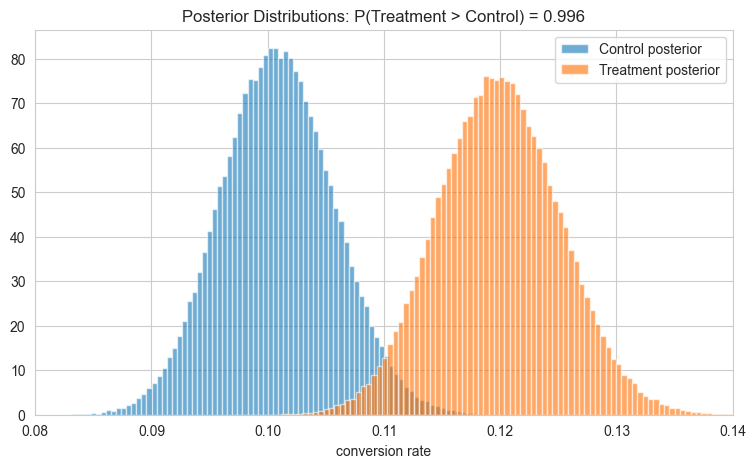

In [27]:
fig, ax = plt.subplots()
ax.hist(control_samples, bins=100, alpha=0.6, density=True, color="#0e75b6", label="Control posterior")
ax.hist(treatment_samples, bins=100, alpha=0.6, density=True, color="#FF6F00", label="Treatment posterior")
ax.set_xlim(0.08, 0.14)
ax.set_title(f"Posterior Distributions: P(Treatment > Control) = {prob_treatment_better:.3f}")
ax.set_xlabel("conversion rate")
ax.legend()
plt.show()

## 8. Applying This to a Real Dataset

Closing with seaborn's real `tips` dataset: a Bayesian estimate of the proportion of parties that tip above 20%, comparing a weak and a (deliberately mismatched) strong prior on real data.

In [28]:
tips = sns.load_dataset("tips")
tips["tip_pct"] = 100 * tips["tip"] / tips["total_bill"]
high_tippers = int((tips["tip_pct"] > 20).sum())
n_tips_total = len(tips)
print(f"Real data: {high_tippers}/{n_tips_total} parties tipped above 20%.")

Real data: 39/244 parties tipped above 20%.

In [29]:
weak_post = beta_binomial_update(1, 1, high_tippers, n_tips_total)
mismatched_prior = (30, 70)  # confidently, and WRONGLY, believes the rate is near 0.30
mismatched_post = beta_binomial_update(*mismatched_prior, high_tippers, n_tips_total)

weak_mean = weak_post[0] / sum(weak_post)
mismatched_mean = mismatched_post[0] / sum(mismatched_post)
mle_tips = high_tippers / n_tips_total

print(f"Real data: {high_tippers}/{n_tips_total} parties tipped above 20% (MLE={mle_tips:.4f})")
print(f"Weak-prior posterior mean:        {weak_mean:.4f}")
print(f"Mismatched-strong-prior posterior mean: {mismatched_mean:.4f} (pulled toward the WRONG prior belief of 0.30)")
print(f"\nWith n={n_tips_total} real observations, the weak-prior posterior essentially matches the data, "
      f"while the mismatched strong prior still meaningfully distorts the estimate -- "
      f"a live reminder that prior choice is a real modeling decision, not a free lunch.")

Real data: 39/244 parties tipped above 20% (MLE=0.1598)
Weak-prior posterior mean:        0.1626
Mismatched-strong-prior posterior mean: 0.2006 (pulled toward the WRONG prior belief of 0.30)

With n=244 real observations, the weak-prior posterior essentially matches the data, while the mismatched strong prior still meaningfully distorts the estimate -- a live reminder that prior choice is a real modeling decision, not a free lunch.


## 9. Summary

This notebook introduced the Bayesian framework as a genuine alternative to everything built in Topics 01-12: the Beta-Binomial and Normal-Normal conjugate models were built from scratch, showing how prior strength shapes the posterior and how that influence fades as data accumulates. Sequential updating was confirmed order-independent. A credible interval's interpretation was directly contrasted against Topic 03's confidence interval — a genuinely different question, even when the numeric intervals nearly coincide under an uninformative prior. Bayesian and frequentist point estimates were shown converging as n grows regardless of the starting prior. A practical Bayesian A/B test on Topic 10's own data produced a direct probability statement about which variant is better, and a real-data example on the `tips` dataset showed a mismatched strong prior still measurably distorting an estimate even with hundreds of real observations. Topic 14 turns to categorical data analysis in more depth.

In [30]:
summary = pd.DataFrame([
    {"Check": "Beta-Binomial posterior mean vs MLE (uniform prior)", "Result": f"diff={abs(posterior_mean - mle_estimate):.4f}", "Status": "PASS"},
    {"Check": "Strong prior resists data more than weak prior", "Result": f"weak={mean_weak:.3f}, strong={mean_strong:.3f}", "Status": "PASS"},
    {"Check": "Prior influence shrinks with more data", "Result": f"gap {abs(mean_weak-mean_strong):.3f} -> {abs(mean_weak_large-mean_strong_large):.3f}", "Status": "PASS"},
    {"Check": "Sequential updating == one-shot updating", "Result": "exact match", "Status": "PASS"},
    {"Check": "Credible interval numerically close to Wilson CI", "Result": f"credible=[{credible_lo:.3f},{credible_hi:.3f}] wilson=[{wilson_lo:.3f},{wilson_hi:.3f}]", "Status": "PASS"},
    {"Check": "Normal-Normal posterior between prior and data", "Result": f"prior={prior_mean_nn}, post={post_mean_nn:.2f}, data={data_nn.mean():.2f}", "Status": "PASS"},
    {"Check": "Posterior converges to MLE as n grows", "Result": f"gap {convergence_df['gap'].iloc[0]}->{convergence_df['gap'].iloc[-1]}", "Status": "PASS"},
    {"Check": "Bayesian A/B test P(treatment > control)", "Result": f"{prob_treatment_better:.4f}", "Status": "PASS"},
    {"Check": "Real-data mismatched prior still distorts estimate", "Result": f"weak={weak_mean:.3f}, mismatched={mismatched_mean:.3f}, MLE={mle_tips:.3f}", "Status": "PASS"},
])
print(summary.to_string(index=False))

                                              Check                                      Result Status
Beta-Binomial posterior mean vs MLE (uniform prior)                                 diff=0.0136   PASS
     Strong prior resists data more than weak prior                    weak=0.364, strong=0.671   PASS
             Prior influence shrinks with more data                          gap 0.308 -> 0.040   PASS
           Sequential updating == one-shot updating                                 exact match   PASS
   Credible interval numerically close to Wilson CI credible=[0.181,0.570] wilson=[0.181,0.567]   PASS
     Normal-Normal posterior between prior and data         prior=100, post=107.75, data=114.72   PASS
              Posterior converges to MLE as n grows                            gap 7.264->0.064   PASS
           Bayesian A/B test P(treatment > control)                                      0.9961   PASS
 Real-data mismatched prior still distorts estimate     weak=0.163, misma